Hae Ji Chong
DSC 680
Project 1


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("airline_financial_impact.csv")

# Preview
print(df.head())
print(df.columns)
print(df.info())
print(df.isnull().sum())

   quarter    month         conflict_phase   airline country       region  \
0  2019-Q1  2019-01  Pre-Pandemic Baseline  Emirates     UAE  Middle East   
1  2019-Q2  2019-04  Pre-Pandemic Baseline  Emirates     UAE  Middle East   
2  2019-Q3  2019-07  Pre-Pandemic Baseline  Emirates     UAE  Middle East   
3  2019-Q4  2019-10  Pre-Pandemic Baseline  Emirates     UAE  Middle East   
4  2020-Q1  2020-01  Pre-Pandemic Baseline  Emirates     UAE  Middle East   

   airline_type  fleet_size  revenue_usd_m  fuel_cost_usd_m  \
0  Flag Carrier         260        7254.03           576.88   
1  Flag Carrier         260        7685.08           567.28   
2  Flag Carrier         260        7655.78           550.04   
3  Flag Carrier         260        7250.33           595.36   
4  Flag Carrier         260        7583.43           583.06   

   fuel_cost_pct_revenue  net_profit_usd_m  profit_margin_pct  \
0                   7.95            995.04              13.72   
1                   7.38    

Data cleaning to convert to the datetime format

In [7]:
# Convert month column to datetime
df["month"] = pd.to_datetime(df["month"])

# Sort by month
df = df.sort_values("month")

# Drop missing values
df = df.dropna()

# Check again
print(df.isnull().sum())

quarter                       0
month                         0
conflict_phase                0
airline                       0
country                       0
region                        0
airline_type                  0
fleet_size                    0
revenue_usd_m                 0
fuel_cost_usd_m               0
fuel_cost_pct_revenue         0
net_profit_usd_m              0
profit_margin_pct             0
passengers_carried_m          0
fuel_hedging_pct              0
hedge_savings_usd_m           0
brent_crude_usd_barrel        0
jet_fuel_usd_barrel           0
daily_fuel_consumption_bbl    0
quarterly_fuel_bbl            0
dtype: int64


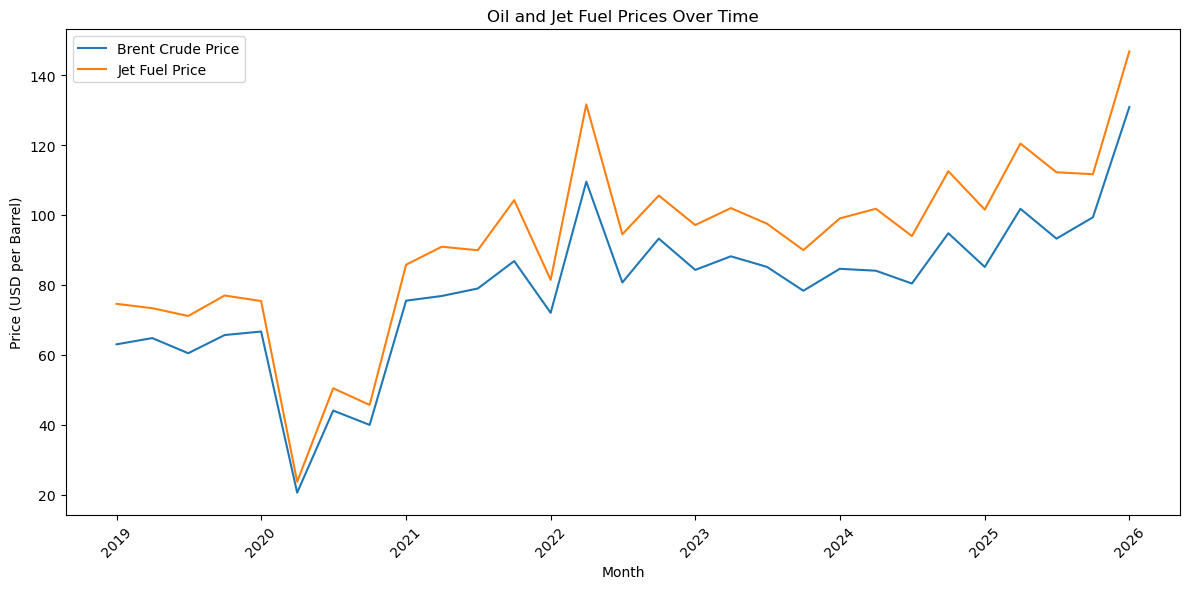

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df.groupby("month")["brent_crude_usd_barrel"].mean(), label="Brent Crude Price")
plt.plot(df.groupby("month")["jet_fuel_usd_barrel"].mean(), label="Jet Fuel Price")
plt.title("Oil and Jet Fuel Prices Over Time")
plt.xlabel("Month")
plt.ylabel("Price (USD per Barrel)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
This shows how oil prices and jet prices change over time. Looking at it, they move in a similar way. 

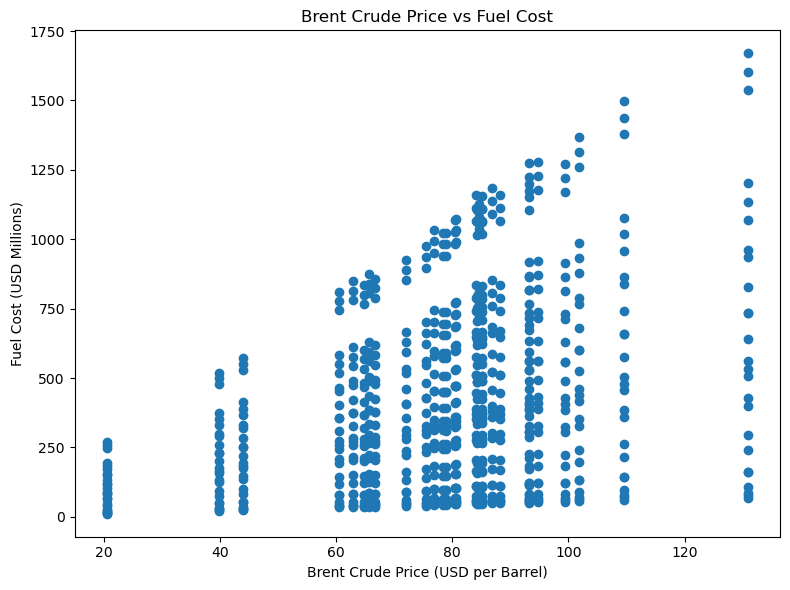

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df["brent_crude_usd_barrel"], df["fuel_cost_usd_m"])
plt.title("Brent Crude Price vs Fuel Cost")
plt.xlabel("Brent Crude Price (USD per Barrel)")
plt.ylabel("Fuel Cost (USD Millions)")
plt.tight_layout()
plt.show()

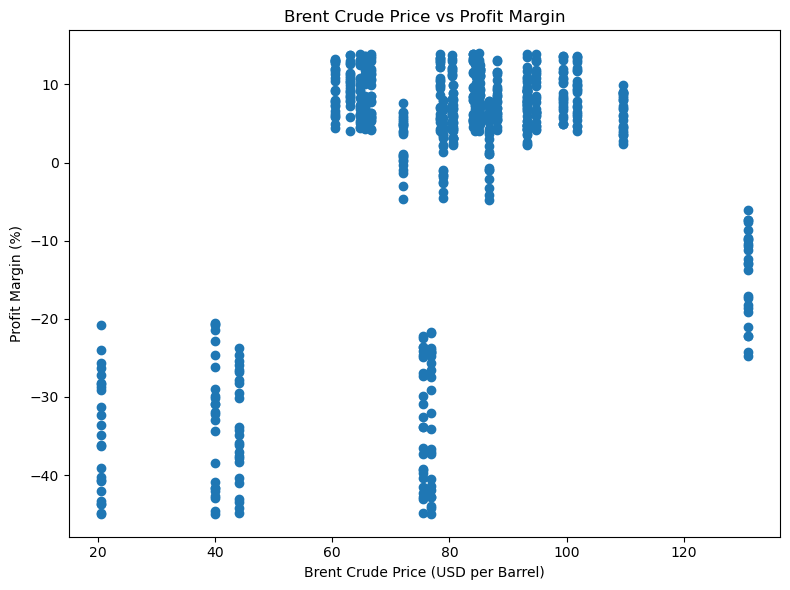

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df["brent_crude_usd_barrel"], df["profit_margin_pct"])
plt.title("Brent Crude Price vs Profit Margin")
plt.xlabel("Brent Crude Price (USD per Barrel)")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

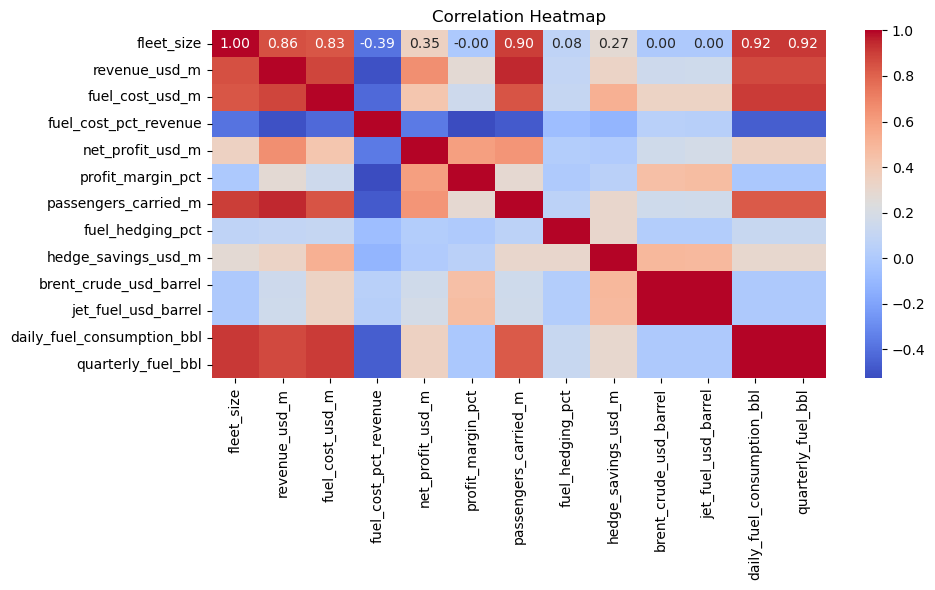

In [27]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

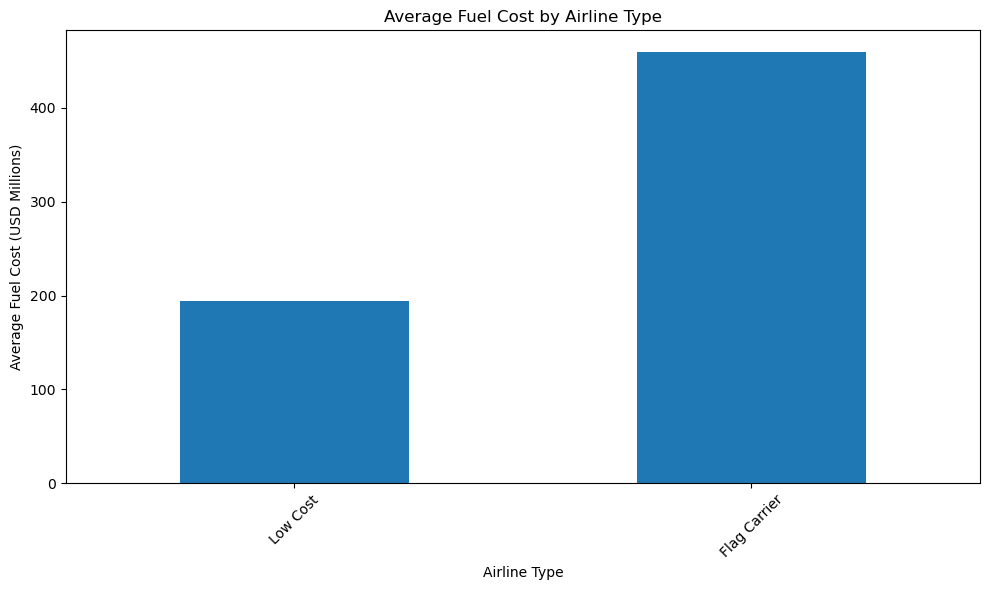

In [19]:
avg_fuel_by_type = df.groupby("airline_type")["fuel_cost_usd_m"].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_fuel_by_type.plot(kind="bar")
plt.title("Average Fuel Cost by Airline Type")
plt.xlabel("Airline Type")
plt.ylabel("Average Fuel Cost (USD Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X = df[["brent_crude_usd_barrel", "jet_fuel_usd_barrel", "daily_fuel_consumption_bbl", "quarterly_fuel_bbl"]]
y = df["fuel_cost_usd_m"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))

MAE: 54.29474716334799
RMSE: 81.57155369254443
R2: 0.9368442567452955


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest MAE: 9.791211034482757
Random Forest RMSE: 17.097414507616133
Random Forest R2: 0.9972254263123842


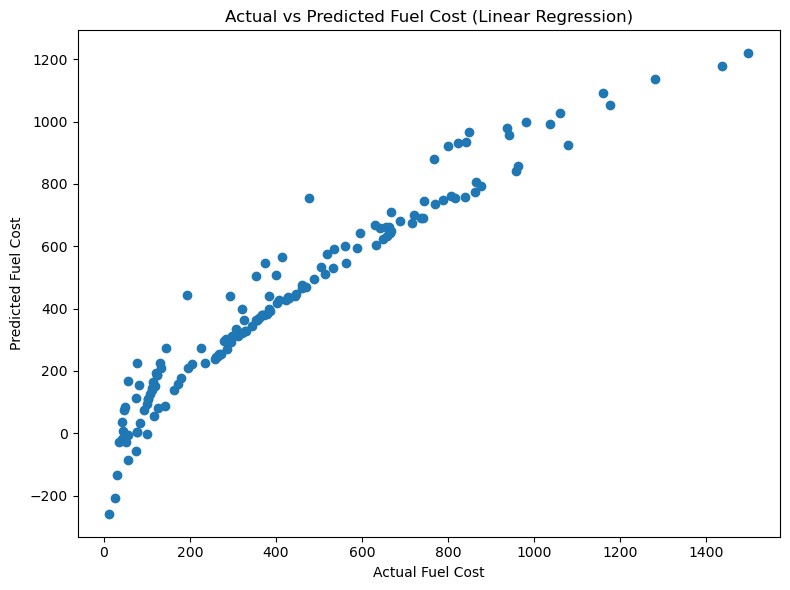

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fuel Cost")
plt.ylabel("Predicted Fuel Cost")
plt.title("Actual vs Predicted Fuel Cost (Linear Regression)")
plt.tight_layout()
plt.show()